# Generate Simulated Data

In [9]:
import pandas as pd
import numpy as np

n_feat = 160
n_samples = 100

mz = np.random.uniform(0, 100, size=n_feat)
rt = np.random.uniform(0, 200, size=n_feat)
X = np.random.exponential(10, size=(n_feat, n_samples))

x_df = pd.DataFrame(
    np.concatenate([mz[:, None], rt[:, None], X], axis=1),
    index=[f"feature{i}" for i in range(n_feat)],
    columns=["mz", "rt"] + [f"sample{i}" for i in range(n_samples)],
)

group_df = pd.DataFrame(
    {
        "class": np.random.choice(["QC", "Subject"], size=n_samples),
        "injection.order": np.random.choice(n_samples, n_samples, replace=False),
        "batch": np.random.choice(4, n_samples, replace=True),
    },
    index=[f"sample{i}" for i in range(n_samples)],
)

x_df.to_csv("./example_x.csv")
group_df.to_csv("./example_sample_info.csv")


# Plot the original data PCA

(100, 160) (100, 3)


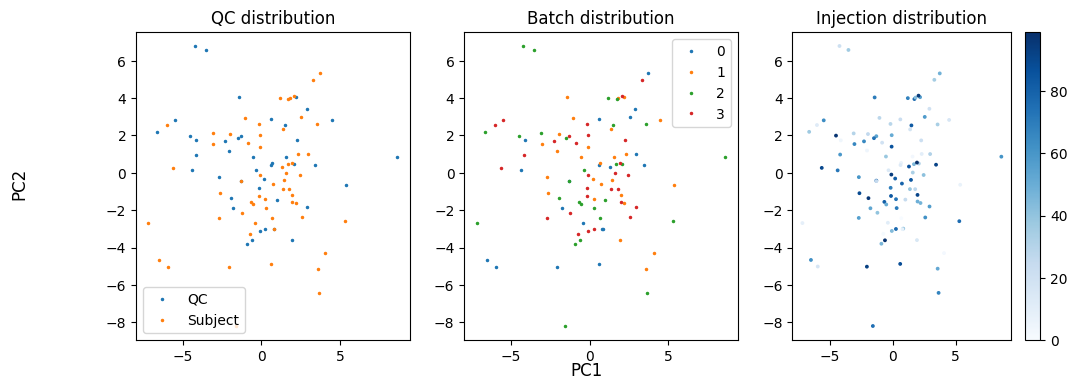

In [10]:
import numpy as np
import pandas as pd
from normae.utils import plot_pca

def get_data(log_transform: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    meta_df = pd.read_csv("./example_x.csv", index_col=0)
    meta_df = meta_df.drop(columns=["mz", "rt"]).T
    info_df = pd.read_csv("./example_sample_info.csv", index_col=0)
    indice_inter = info_df.index.intersection(meta_df.index)
    meta_df = meta_df.loc[indice_inter]
    info_df = info_df.loc[indice_inter]

    mask1 = (meta_df == 0).mean(axis=0) < 0.2
    meta_df = meta_df.loc[:, mask1]

    qc_mask = info_df["class"] == "QC"
    qc_meta_df = meta_df.loc[qc_mask, :]
    mask2 = (qc_meta_df == 0).mean(axis=0) < 0.2
    meta_df = meta_df.loc[:, mask2]

    def impute_zero(peak):
        zero_mask = peak == 0
        if zero_mask.any():
            new_x = peak.copy()
            impute_value = peak.loc[~zero_mask].min()
            new_x[zero_mask] = impute_value / 2
            return new_x
        return peak
    meta_df = meta_df.apply(impute_zero, axis=0)    
    info_df = info_df.loc[:, ["injection.order", "batch", "class"]]

    if log_transform:
        meta_df = meta_df.map(np.log)
    print(meta_df.shape, info_df.shape)
    return meta_df, info_df


meta_df, info_df = get_data(log_transform=True)

x_orig = meta_df.values
fig, _ = plot_pca(
    x_orig,
    qc=info_df["class"].values,
    batch=info_df["batch"].values,
    injection=info_df["injection.order"].values,
)
